# Week 4 — Linear Regression Model

**What you will do this week:**
1. Understand what linear regression is
2. Prepare features for the model
3. Train a linear regression model
4. Evaluate how good the model is
5. Interpret the results in plain language

**The question we are trying to answer:**
> Can we predict how many days of stock a facility will have, based on what we know about it?

If we can, the model could flag facilities that are likely to run low *before* they actually do.

---

## 1. What is linear regression?

Linear regression finds the best straight line through your data.

For example: if you know that hospitals generally have more days of stock than health posts,
a linear regression will learn that pattern from the data and use it to make predictions.

The output of the model is a formula like:

```
days_of_stock = (weight_1 × facility_type) + (weight_2 × zone) + (weight_3 × consumption) + ...
```

The model learns the weights from the data. Our job is to:
1. Choose which inputs (called **features**) to give it
2. Train it on part of the data
3. Test it on data it has never seen before

---

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

stock = pd.read_csv('../data/stock_clean.csv')
print(f'Loaded {len(stock):,} rows')
stock.head()

Loaded 2,149 rows


,facility_id,facility_type,zone,lead_time_days,medicine,month,stock_on_hand,consumption,resupply,days_of_stock,stockout
0,ETH001,Health Centre,SNNPR,21,Oxytocin,2024-01,72.0,27,0,80.0,0
1,ETH001,Health Centre,SNNPR,21,Oxytocin,2024-02,44.0,28,0,47.1,0
2,ETH001,Health Centre,SNNPR,21,Oxytocin,2024-03,24.0,20,0,36.0,0
3,ETH001,Health Centre,SNNPR,21,Oxytocin,2024-04,68.0,25,69,81.6,0
4,ETH001,Health Centre,SNNPR,21,Oxytocin,2024-05,40.0,28,0,42.9,0


## 2. Choose features

**Features** are the columns we give to the model as inputs.
**Target** is what we want the model to predict — in our case, `days_of_stock`.

We will use:
- `facility_type` — hospitals tend to have more stock than health posts
- `zone` — some zones have better supply chains than others
- `consumption` — higher consumption burns through stock faster
- `lead_time_days` — facilities with long lead times need more buffer stock
- `medicine` — different medicines have different supply patterns

Linear regression needs numbers, not text. We convert text columns to numbers
using `LabelEncoder`.

In [3]:
# Make a copy so we don't change the original data
df = stock.copy()

# Convert text columns to numbers
label_cols = ['facility_type', 'zone', 'medicine']

# We save the encoders so we can decode later if needed
encoders = {}
for col in label_cols:
    le = LabelEncoder()
    df[col + '_encoded'] = le.fit_transform(df[col])
    encoders[col] = le
    print(f'{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

facility_type: {'Health Centre': np.int64(0), 'Health Post': np.int64(1), 'Hospital': np.int64(2)}
zone: {'Amhara': np.int64(0), 'Oromia': np.int64(1), 'SNNPR': np.int64(2), 'Tigray': np.int64(3)}
medicine: {'Artemether-Lumefantrine': np.int64(0), 'Magnesium Sulphate': np.int64(1), 'ORS/Zinc': np.int64(2), 'Oxytocin': np.int64(3)}


In [4]:
# Define features (X) and target (y)
feature_cols = [
    'facility_type_encoded',
    'zone_encoded',
    'medicine_encoded',
    'consumption',
    'lead_time_days',
]

X = df[feature_cols]
y = df['days_of_stock']

print(f'Features shape: {X.shape}')  # (rows, columns)
print(f'Target shape:   {y.shape}')
X.head()

Features shape: (2149, 5)
Target shape:   (2149,)


,facility_type_encoded,zone_encoded,medicine_encoded,consumption,lead_time_days
0,0,2,3,27,21
1,0,2,3,28,21
2,0,2,3,20,21
3,0,2,3,25,21
4,0,2,3,28,21


## 3. Split into training and test sets

We split the data into two parts:
- **Training set (80%)** — the model learns from this
- **Test set (20%)** — we use this to check how well the model performs on data it has never seen

This is important: if we tested on the same data we trained on, the model would look much
better than it really is.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training rows:  {len(X_train)}')
print(f'Test rows:      {len(X_test)}')

Training rows:  1719
Test rows:      430


## 4. Train the model

Training the model means finding the weights that best fit the training data.
With scikit-learn, this is just two lines.

In [6]:
model = LinearRegression()
model.fit(X_train, y_train)

print('Model trained!')
print(f'Intercept: {model.intercept_:.2f}')

Model trained!
Intercept: 61.89


## 5. Look at what the model learned

The model learned a weight (called a **coefficient**) for each feature.
A positive coefficient means that feature increases days of stock.
A negative coefficient means it decreases days of stock.

In [7]:
coefficients = pd.DataFrame({
    'feature':     feature_cols,
    'coefficient': model.coef_
}).sort_values('coefficient', key=abs, ascending=False)

print('What the model learned:')
print(coefficients.to_string(index=False))

What the model learned:
              feature  coefficient
     medicine_encoded     2.530315
facility_type_encoded     1.960916
          consumption    -0.331537
         zone_encoded    -0.272525
       lead_time_days     0.138490


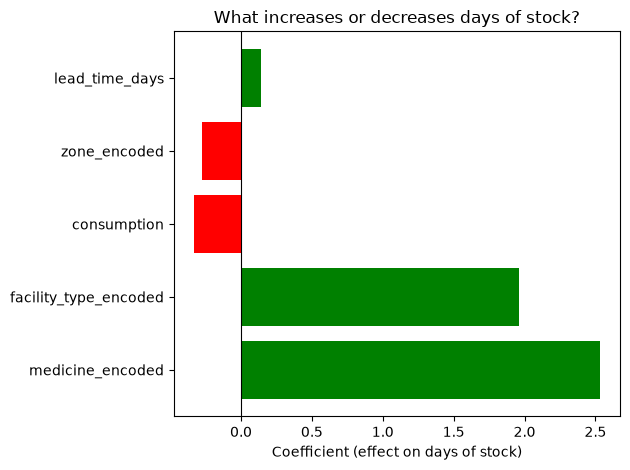

In [8]:
# Bar chart of coefficients
colors = ['green' if c > 0 else 'red' for c in coefficients['coefficient']]
plt.barh(coefficients['feature'], coefficients['coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coefficient (effect on days of stock)')
plt.title('What increases or decreases days of stock?')
plt.tight_layout()
plt.show()

## 6. Evaluate the model

We measure model performance with two numbers:

- **MAE (Mean Absolute Error):** on average, how many days off is the prediction?
  - Example: MAE = 12 means the model is wrong by about 12 days on average
  - Lower is better

- **R² (R-squared):** how much of the variation does the model explain?
  - 1.0 = perfect predictions
  - 0.0 = the model is no better than just predicting the average every time
  - Higher is better

In [9]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print(f'Mean Absolute Error (MAE): {mae:.1f} days')
print(f'R² score:                  {r2:.3f}')
print()
if r2 > 0.6:
    print('The model explains a reasonable amount of variation in days of stock.')
elif r2 > 0.3:
    print('The model explains some variation but many other factors are at play.')
else:
    print('The model has low R². Days of stock is hard to predict from these features alone.')

Mean Absolute Error (MAE): 36.6 days
R² score:                  -0.013

The model has low R². Days of stock is hard to predict from these features alone.


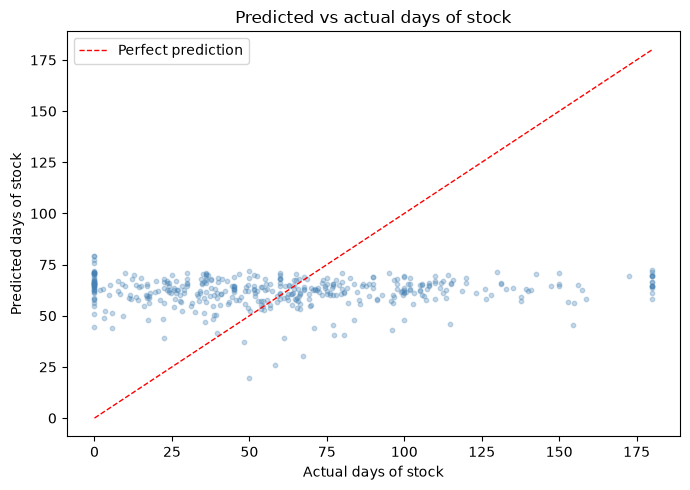

If the model were perfect, all dots would sit on the red dashed line.


In [10]:
# Predicted vs actual scatter plot
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue', s=10)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', linewidth=1, label='Perfect prediction')
plt.xlabel('Actual days of stock')
plt.ylabel('Predicted days of stock')
plt.title('Predicted vs actual days of stock')
plt.legend()
plt.tight_layout()
plt.show()

print('If the model were perfect, all dots would sit on the red dashed line.')

## 7. Write up your findings

Complete the cells below with your own words. This is the most important part.
A model that nobody can understand is not useful.

### What did the model find?

*Edit this cell with your findings. Answer:*
- *Which feature had the biggest effect on days of stock?*
- *Did higher consumption lead to more or fewer days of stock? Does that make sense?*
- *Did facility type matter? Which type had more stock?*

*(Your answer here)*

### How accurate is the model?

*Edit this cell. Answer:*
- *What was the MAE? Is that good or bad for a health supply chain context?*
- *What was the R²? What does that tell you?*
- *Would you trust this model to make real decisions? Why or why not?*

*(Your answer here)*

### What are the limitations?

*Edit this cell. Answer:*
- *What important information do we NOT have that would improve the model?*
- *Is this data from real facilities or synthetic? Why does that matter?*
- *What would need to happen before this model could be used in the real Ethiopia programme?*

*(Your answer here)*

---
## ✅ Week 4 checklist

- [ ] Model trained successfully
- [ ] Coefficients table printed and chart produced
- [ ] MAE and R² calculated and recorded
- [ ] Predicted vs actual scatter plot produced
- [ ] Findings written up in plain language (the three cells above)
- [ ] Limitations section completed

**Congratulations — you have completed the UC 3.2 intern project!**

Your final submission should include:
1. This notebook with all cells run and findings written
2. A screenshot of your Superset dashboard
3. A short (1 page) summary of what you built and what you found